In [1]:
import json
import os
import re
import string
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [ ]:

DATA_DIR = "../data/dataset"
JSON_PATH = os.path.join(DATA_DIR, "pavbhaji.json")
IMAGE_DIR = os.path.join(DATA_DIR, "images")

print("JSON path:", JSON_PATH)
print("Image directory:", IMAGE_DIR)

print("JSON exists:", os.path.exists(JSON_PATH))
print("Image directory exists:", os.path.exists(IMAGE_DIR))

JSON path: ../data/dataset/pavbhaji.json
Image directory: ../data/dataset/images
JSON exists: True
Image directory exists: True


In [4]:

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Data type:", type(data))
print("Number of records:", len(data))


Data type: <class 'list'>
Number of records: 1500


In [6]:

df_raw = pd.DataFrame(data)

print("Dataset shape:", df_raw.shape)

print("\nAvailable columns:")
for column in df_raw.columns:
    print("-", column)

Dataset shape: (1500, 18)

Available columns:
- dimensions
- display_url
- edge_liked_by
- edge_media_preview_like
- edge_media_to_caption
- edge_media_to_comment
- id
- is_video
- location
- owner
- shortcode
- tags
- taken_at_timestamp
- thumbnail_resources
- thumbnail_src
- urls
- video_view_count
- comments_disabled


In [7]:
df_raw.head(3)

,dimensions,display_url,edge_liked_by,edge_media_preview_like,edge_media_to_caption,edge_media_to_comment,id,is_video,location,owner,shortcode,tags,taken_at_timestamp,thumbnail_resources,thumbnail_src,urls,video_view_count,comments_disabled
0,"{'height': 734, 'width': 640}",https://instagram.fpnq3-1.fna.fbcdn.net/vp/352...,{'count': 3797},{'count': 3797},{'edges': [{'node': {'text': 'TAG A PAV BHAJI ...,{'count': 52},1834712933156555738,True,None,{'id': '1919686029'},Bl2NbElnIva,"[vadapav, foodgram, foodphotography, foodblogg...",1532934873,"[{'config_height': 150, 'config_width': 150, '...",https://instagram.fpnq3-1.fna.fbcdn.net/vp/cb5...,[https://instagram.fpnq3-1.fna.fbcdn.net/vp/89...,0.0,NaN
1,"{'height': 750, 'width': 750}",https://instagram.fpnq3-1.fna.fbcdn.net/vp/b0d...,{'count': 12041},{'count': 12041},{'edges': [{'node': {'text': 'देसी स्टाइल पाव ...,{'count': 325},1826000656302706137,True,"{'has_public_page': True, 'id': '245717485', '...",{'id': '1445587278'},BlXQewejY3Z,"[healthyfood, sokolkata, mumbaifoodie, faridab...",1531897016,"[{'config_height': 150, 'config_width': 150, '...",https://instagram.fpnq3-1.fna.fbcdn.net/vp/ad3...,[https://instagram.fpnq3-1.fna.fbcdn.net/vp/9c...,0.0,NaN
2,"{'height': 800, 'width': 640}",https://instagram.fpnq3-1.fna.fbcdn.net/vp/cb4...,{'count': 3544},{'count': 3544},{'edges': [{'node': {'text': 'Pav Bhaji😍😍😋\n.\...,{'count': 18},1849962218902145720,True,"{'has_public_page': True, 'id': '213724095', '...",{'id': '4759392841'},BmsYtYpjkq4,"[foodphotography, mumbaipeople, vascom, delhib...",1534752790,"[{'config_height': 150, 'config_width': 150, '...",https://instagram.fpnq3-1.fna.fbcdn.net/vp/64f...,[https://instagram.fpnq3-1.fna.fbcdn.net/vp/5e...,0.0,NaN


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dimensions               1500 non-null   object 
 1   display_url              1500 non-null   str    
 2   edge_liked_by            1500 non-null   object 
 3   edge_media_preview_like  1500 non-null   object 
 4   edge_media_to_caption    1500 non-null   object 
 5   edge_media_to_comment    1500 non-null   object 
 6   id                       1500 non-null   str    
 7   is_video                 1500 non-null   bool   
 8   location                 924 non-null    object 
 9   owner                    1500 non-null   object 
 10  shortcode                1500 non-null   str    
 11  tags                     1499 non-null   object 
 12  taken_at_timestamp       1500 non-null   int64  
 13  thumbnail_resources      1500 non-null   object 
 14  thumbnail_src            1500 non-n

In [9]:
df_raw.isnull().sum()

dimensions                    0
display_url                   0
edge_liked_by                 0
edge_media_preview_like       0
edge_media_to_caption         0
edge_media_to_comment         0
id                            0
is_video                      0
location                    576
owner                         0
shortcode                     0
tags                          1
taken_at_timestamp            0
thumbnail_resources           0
thumbnail_src                 0
urls                          0
video_view_count           1390
comments_disabled             9
dtype: int64

In [10]:

image_dir_0 = os.path.join(IMAGE_DIR, "0")
image_dir_1 = os.path.join(IMAGE_DIR, "1")

images_0 = [
    f for f in os.listdir(image_dir_0)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

images_1 = [
    f for f in os.listdir(image_dir_1)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Class 0 images:", len(images_0))
print("Class 1 images:", len(images_1))
print("Total images:", len(images_0) + len(images_1))

Class 0 images: 269
Class 1 images: 183
Total images: 452


In [11]:

image_labels = {}

for filename in images_0:
    image_labels[filename] = 0

for filename in images_1:
    image_labels[filename] = 1

print("Total labeled images:", len(image_labels))

Total labeled images: 452


In [12]:

records = []

for item in data:
    display_url = item.get("display_url", "")
    image_name = os.path.basename(display_url)

    if image_name in image_labels:
        records.append({
            "image": image_name,
            "label": image_labels[image_name],
            "data": item
        })

print("JSON records:", len(data))
print("Matched records:", len(records))
print("Unmatched records:", len(data) - len(records))

JSON records: 1500
Matched records: 452
Unmatched records: 1048


In [13]:
def extract_caption(item):
    caption_data = item.get("edge_media_to_caption", {})
    
    edges = caption_data.get("edges", [])
    
    if edges:
        return edges[0].get("node", {}).get("text", "")
    
    return ""

In [14]:

clean_records = []

for record in records:
    item = record["data"]
    
    clean_records.append({
        "image": record["image"],
        "label": record["label"],
        "caption": extract_caption(item),
        "tags": item.get("tags", []),
        "is_video": item.get("is_video", False),
        "video_view_count": item.get("video_view_count", 0),
        "shortcode": item.get("shortcode", ""),
        "post_id": item.get("id", "")
    })

ml_df = pd.DataFrame(clean_records)

print("ML dataset shape:", ml_df.shape)

ML dataset shape: (452, 8)


In [15]:
ml_df.head()

,image,label,caption,tags,is_video,video_view_count,shortcode,post_id
0,39790065_708138802879611_4373499256883904512_n...,0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_te...,"[westbengal, iphone, delhifoodie, sokolkata, m...",False,0,Bm_FGwUH9l9,1855224025926588797
1,39205669_548076665624561_2856530375738392576_n...,1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\n...","[foodgram, foodphotography, foodblogger, foodm...",False,0,Bm_CVxfHNd-,1855211863837300606
2,39928567_2025694197741778_2817802553157661723_...,0,Follow @dilliciousfoodie \n@dilliciousfoodie \...,"[foodphotography, bhaji, pasta, fries, f52gram...",False,0,Bm_BPiCH4hM,1855207036881438796
3,39991006_472180219962850_7601786252118982656_n...,0,We’ve got you some delicious evening snacks💯\n...,"[UpcyclingFood, Twist, LeftoverPavBhajiBreadPa...",False,0,Bm--S3NF5Bi,1855194071632941154
4,37158549_528309647598249_6068909533663592448_n...,0,People who love food are the best 😁\n.\n.\n.\n...,"[foodphotography, lonidosa, tbt, foodie, mahar...",False,0,Bm-97W0BQyn,1855192456304594087


In [16]:
print("Class distribution:")
print(ml_df["label"].value_counts())

print("\nClass percentage:")
print((ml_df["label"].value_counts(normalize=True) * 100).round(2))

Class distribution:
label
0    269
1    183
Name: count, dtype: int64

Class percentage:
label
0    59.51
1    40.49
Name: proportion, dtype: float64


In [17]:
pd.set_option("display.max_colwidth", 200)

ml_df[["label", "caption", "tags"]].head(10)

,label,caption,tags
0,0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_teekhi_mirchi .\n.\n.\n@zingyzest \n@saadidilli \n@thegreatindianfoodie \n@khaata_rahe_mera_dil \n@khau_gali_foodie \n@dillifoodjunkie \n@foodiebaniya \...,"[westbengal, iphone, delhifoodie, sokolkata, mumbaifoodie, mumbaifoodbloggers, waiwai, chicken, chickentikka, delhieater, iphonephotography, foodporn, platter, delhifood, nomnom, nepal, bengluru, ..."
1,1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\nYe achhi thi 😍\nAt Vega pure vegetarian, CP\n.\n.\n.\nTag your people who will love this 😋 and share this with them\n.\n.\n.\nFollow my foodie journey...","[foodgram, foodphotography, foodblogger, foodmaniacindia, delhifoodie, mumbai, foodie, indianfoodie, mumbaifoodie, foodblogging, indianfood, snacks, delhidiaries, foodporn, cheese, foodtography, f..."
2,0,Follow @dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie .\n.\n.\n➖➖➖➖\n.\n.\n#dillifoodjunkie #foodforlife #pasta #food #pavbha...,"[foodphotography, bhaji, pasta, fries, f52grams, indianfood, likeforlike, snacks, butterchicken, chicken, starbucks, spicy, yum, india, cheesyfries, yummy, dillifoodjunkie, mumbaifoodblogger, yumm..."
3,0,We’ve got you some delicious evening snacks💯\n.\n.\n.\n#LeftoverPavBhajiBreadPakoda #PavBhaji #BreadPakoda #LeftoverFood #UpcyclingFood #Marathi #Maharashtrian #RecipeOfTheDay #Innovative #Foodies...,"[UpcyclingFood, Twist, LeftoverPavBhajiBreadPakoda, FoodForLife, Maharashtrian, ASI, Innovative, Foodies, YummyTreat, Recipes, BreadPakoda, Homemade, DishesWithATwist, Treat, RecipeOfTheDay, Lefto..."
4,0,People who love food are the best 😁\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n#food #foods #foodie #foody #foodporn #foodshot #foodgasm #foodphotography #foodpics #foodstagram #tbt #f...,"[foodphotography, lonidosa, tbt, foodie, maharashtra, foodpics, foodography, thali, thalipeeth, instafood, foodporn, foodblog, goodfood, omnom, nomnom, india, bhelpuri, foodshot, foodiegram, foods..."
5,0,Transforming simple Pav Bhaji into some delicious Bread Pakodas💯\n.\n.\n.\n#LeftoverPavBhajiBreadPakoda #PavBhaji #BreadPakoda #LeftoverFood #UpcyclingFood #Marathi #Maharashtrian #RecipeOfTheDay ...,"[UpcyclingFood, Twist, LeftoverPavBhajiBreadPakoda, FoodForLife, Maharashtrian, ASI, Innovative, Foodies, YummyTreat, Recipes, BreadPakoda, Homemade, DishesWithATwist, Treat, RecipeOfTheDay, Lefto..."
6,1,Pav Bhaji at Mazgaon Khaugalli\n\nDevoured this piping hot Pav Bhaji at the little known Mazgaon Khaugalli.\nThis street gets filled with lots of stalls in evening right from Chaat to Tandoor Pane...,"[mumbai, mumbaifoodie, vscofoodie, indianfoodbloggers, comfortfood, navimumbaifoodie, indianfood, cheese, desifood, streetfoods, delhifood, cheesegasm, TheSaucyXplorer, mumbaiblogger, fooddiary, f..."
7,1,"P A P P I L O N\nThat's one of the delicious Pav Bhajji from Papillon Vile parle.\nThis place is right in Irla, near Khadi office.\nThe place is worth having Pav Bhajji & also it has a great servi...","[burgerfuel, foodphotography, foodblogger, burgerlove, burgerliebe, delicious, burgerman, foodlover, burgertime, cheeseburger, burgergram, instafood, burgermeister, burgerporn, kerala, burgerland,..."
8,1,PAV BHAJI wala Mausam hai aaj Nagpur me 😍☔\n.\nTag your bhukkad friend in the comments below 😄\n.\nFollow @thebhukkadgang_nagpur .\nTurn on the post notification 🔔\n.\n#pavbhaji #monsoon #nagpurba...,"[mumbai, itz_mumbai, mumbaifoodie, nagpurdiaries, nagpurkar, maharashtra, mumbai_ig, mumbai_diaries, nagpur_boys_nd_girls_shoutout, nagpurian, mumbai_uncensored, nagpuri, nagpur, mumbai_igers, del..."
9,0,Such a colourful Sprouts Chaat 😛\n.\n.\n.\n.\n.\n.\n. .\n.\n.\n.\n.\n.\n. .\n.\n#samosa #thali #mumbai_igers #kolkatadiaries #newdelhi #sprouts #kolkata #delhi_igers #mymumbai #delhidiaries #india...,"[vadapav, delhifoodie, mumbaifoodie, newdelhi, kolkatadiaries, mymumbai, thali, delhidiaries, golgappa, mumbai_igers,

In [18]:
print("ML dataset shape:", ml_df.shape)
print(ml_df["label"].value_counts())
ml_df[["label", "caption", "tags"]].head()

ML dataset shape: (452, 8)
label
0    269
1    183
Name: count, dtype: int64


,label,caption,tags
0,0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_teekhi_mirchi .\n.\n.\n@zingyzest \n@saadidilli \n@thegreatindianfoodie \n@khaata_rahe_mera_dil \n@khau_gali_foodie \n@dillifoodjunkie \n@foodiebaniya \...,"[westbengal, iphone, delhifoodie, sokolkata, mumbaifoodie, mumbaifoodbloggers, waiwai, chicken, chickentikka, delhieater, iphonephotography, foodporn, platter, delhifood, nomnom, nepal, bengluru, ..."
1,1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\nYe achhi thi 😍\nAt Vega pure vegetarian, CP\n.\n.\n.\nTag your people who will love this 😋 and share this with them\n.\n.\n.\nFollow my foodie journey...","[foodgram, foodphotography, foodblogger, foodmaniacindia, delhifoodie, mumbai, foodie, indianfoodie, mumbaifoodie, foodblogging, indianfood, snacks, delhidiaries, foodporn, cheese, foodtography, f..."
2,0,Follow @dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie .\n.\n.\n➖➖➖➖\n.\n.\n#dillifoodjunkie #foodforlife #pasta #food #pavbha...,"[foodphotography, bhaji, pasta, fries, f52grams, indianfood, likeforlike, snacks, butterchicken, chicken, starbucks, spicy, yum, india, cheesyfries, yummy, dillifoodjunkie, mumbaifoodblogger, yumm..."
3,0,We’ve got you some delicious evening snacks💯\n.\n.\n.\n#LeftoverPavBhajiBreadPakoda #PavBhaji #BreadPakoda #LeftoverFood #UpcyclingFood #Marathi #Maharashtrian #RecipeOfTheDay #Innovative #Foodies...,"[UpcyclingFood, Twist, LeftoverPavBhajiBreadPakoda, FoodForLife, Maharashtrian, ASI, Innovative, Foodies, YummyTreat, Recipes, BreadPakoda, Homemade, DishesWithATwist, Treat, RecipeOfTheDay, Lefto..."
4,0,People who love food are the best 😁\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n#food #foods #foodie #foody #foodporn #foodshot #foodgasm #foodphotography #foodpics #foodstagram #tbt #f...,"[foodphotography, lonidosa, tbt, foodie, maharashtra, foodpics, foodography, thali, thalipeeth, instafood, foodporn, foodblog, goodfood, omnom, nomnom, india, bhelpuri, foodshot, foodiegram, foods..."


In [19]:
def combine_text(row):
    caption = row["caption"] if isinstance(row["caption"], str) else ""
    tags = row["tags"] if isinstance(row["tags"], list) else []
    tags_text = " ".join(str(tag) for tag in tags)
    return caption + " " + tags_text

ml_df["raw_text"] = ml_df.apply(combine_text, axis=1)

ml_df[["label", "raw_text"]].head()

,label,raw_text
0,0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_teekhi_mirchi .\n.\n.\n@zingyzest \n@saadidilli \n@thegreatindianfoodie \n@khaata_rahe_mera_dil \n@khau_gali_foodie \n@dillifoodjunkie \n@foodiebaniya \...
1,1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\nYe achhi thi 😍\nAt Vega pure vegetarian, CP\n.\n.\n.\nTag your people who will love this 😋 and share this with them\n.\n.\n.\nFollow my foodie journey..."
2,0,Follow @dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie .\n.\n.\n➖➖➖➖\n.\n.\n#dillifoodjunkie #foodforlife #pasta #food #pavbha...
3,0,We’ve got you some delicious evening snacks💯\n.\n.\n.\n#LeftoverPavBhajiBreadPakoda #PavBhaji #BreadPakoda #LeftoverFood #UpcyclingFood #Marathi #Maharashtrian #RecipeOfTheDay #Innovative #Foodies...
4,0,People who love food are the best 😁\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n#food #foods #foodie #foody #foodporn #foodshot #foodgasm #foodphotography #foodpics #foodstagram #tbt #f...


In [20]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"\\n", " ", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ml_df["clean_text"] = ml_df["raw_text"].apply(clean_text)

ml_df[["label", "raw_text", "clean_text"]].head()

,label,raw_text,clean_text
0,0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_teekhi_mirchi .\n.\n.\n@zingyzest \n@saadidilli \n@thegreatindianfoodie \n@khaata_rahe_mera_dil \n@khau_gali_foodie \n@dillifoodjunkie \n@foodiebaniya \...,chicken tikka follow vlogger chicken chickentikka chickentikkamasala sokolkata westbengal delhifoodblogger delhifoodguide delhi_igers delhifoodie delhifood somumbai mumbaifood mumbaifoodie mumbaif...
1,1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\nYe achhi thi 😍\nAt Vega pure vegetarian, CP\n.\n.\n.\nTag your people who will love this 😋 and share this with them\n.\n.\n.\nFollow my foodie journey...",hello frandz pav bhaji khaalo garam hai ye achhi thi at vega pure vegetarian cp tag your people who will love this and share this with them follow my foodie journey follow foodiebaniya foodiejyoti...
2,0,Follow @dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie \n@dilliciousfoodie .\n.\n.\n➖➖➖➖\n.\n.\n#dillifoodjunkie #foodforlife #pasta #food #pavbha...,follow dillifoodjunkie foodforlife pasta food pavbhaji chicken butterchicken indianfood india tasty foodgasm yummyinmytummy foodphotography streetfood lifestyle snacks yummy yum likeforlike sodelh...
3,0,We’ve got you some delicious evening snacks💯\n.\n.\n.\n#LeftoverPavBhajiBreadPakoda #PavBhaji #BreadPakoda #LeftoverFood #UpcyclingFood #Marathi #Maharashtrian #RecipeOfTheDay #Innovative #Foodies...,we ve got you some delicious evening snacks leftoverpavbhajibreadpakoda pavbhaji breadpakoda leftoverfood upcyclingfood marathi maharashtrian recipeoftheday innovative foodies treat yummytreat yum...
4,0,People who love food are the best 😁\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n.\n#food #foods #foodie #foody #foodporn #foodshot #foodgasm #foodphotography #foodpics #foodstagram #tbt #f...,people who love food are the best food foods foodie foody foodporn foodshot foodgasm foodphotography foodpics foodstagram tbt foodography instafood foodblog foodiegram foodielife kolhapur maharash...


In [21]:
print("Empty text records:", (ml_df["clean_text"].str.len() == 0).sum())

Empty text records: 0


In [22]:
ml_df[ml_df["clean_text"].str.len() == 0][["image", "label"]]

,image,label


In [23]:
X = ml_df["clean_text"]
y = ml_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 361
Testing samples: 91


In [24]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

tfidf_lr.fit(X_train, y_train)

y_pred_lr = tfidf_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.48      0.60        54
           1       0.53      0.84      0.65        37

    accuracy                           0.63        91
   macro avg       0.67      0.66      0.63        91
weighted avg       0.70      0.63      0.62        91



In [25]:
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
}

lr_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.6263736263736264,
 'Precision': 0.5254237288135594,
 'Recall': 0.8378378378378378,
 'F1 Score': 0.6458333333333334}

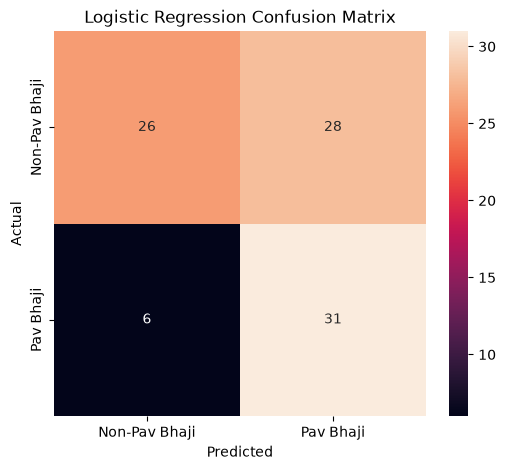

In [26]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Pav Bhaji", "Pav Bhaji"],
    yticklabels=["Non-Pav Bhaji", "Pav Bhaji"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [27]:
tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

tfidf_svm.fit(X_train, y_train)

y_pred_svm = tfidf_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.73      0.59      0.65        54
           1       0.53      0.68      0.60        37

    accuracy                           0.63        91
   macro avg       0.63      0.63      0.62        91
weighted avg       0.65      0.63      0.63        91



In [28]:
svm_metrics = {
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm)
}

svm_metrics

{'Model': 'Linear SVM',
 'Accuracy': 0.6263736263736264,
 'Precision': 0.5319148936170213,
 'Recall': 0.6756756756756757,
 'F1 Score': 0.5952380952380952}

In [29]:
tfidf_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("model", MultinomialNB())
])

tfidf_nb.fit(X_train, y_train)

y_pred_nb = tfidf_nb.predict(X_test)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.62      0.65      0.64        54
           1       0.46      0.43      0.44        37

    accuracy                           0.56        91
   macro avg       0.54      0.54      0.54        91
weighted avg       0.56      0.56      0.56        91



In [30]:
nb_metrics = {
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1 Score": f1_score(y_test, y_pred_nb)
}

nb_metrics

{'Model': 'Naive Bayes',
 'Accuracy': 0.5604395604395604,
 'Precision': 0.45714285714285713,
 'Recall': 0.43243243243243246,
 'F1 Score': 0.4444444444444444}

In [31]:
results = pd.DataFrame([
    lr_metrics,
    svm_metrics,
    nb_metrics
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.626374,0.525424,0.837838,0.645833
1,Linear SVM,0.626374,0.531915,0.675676,0.595238
2,Naive Bayes,0.560440,0.457143,0.432432,0.444444


In [32]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6264,0.5254,0.8378,0.6458
1,Linear SVM,0.6264,0.5319,0.6757,0.5952
2,Naive Bayes,0.5604,0.4571,0.4324,0.4444


In [33]:
results.to_csv("../reports/model_comparison.csv", index=False)

In [34]:
ml_df["contains_pavbhaji"] = ml_df["clean_text"].str.contains(
    r"\bpav\s*bhaji\b|\bpavbhaji\b",
    regex=True,
    case=False
)

print(pd.crosstab(ml_df["label"], ml_df["contains_pavbhaji"]))

contains_pavbhaji  False  True 
label                          
0                      2    267
1                      0    183


In [35]:
def remove_pavbhaji(text):
    text = re.sub(r"\bpav\s*bhaji\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\bpavbhaji\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ml_df["clean_text_no_keyword"] = ml_df["clean_text"].apply(remove_pavbhaji)

ml_df[["label", "clean_text_no_keyword"]].head()

,label,clean_text_no_keyword
0,0,chicken tikka follow vlogger chicken chickentikka chickentikkamasala sokolkata westbengal delhifoodblogger delhifoodguide delhi_igers delhifoodie delhifood somumbai mumbaifood mumbaifoodie mumbaif...
1,1,hello frandz khaalo garam hai ye achhi thi at vega pure vegetarian cp tag your people who will love this and share this with them follow my foodie journey follow foodiebaniya foodiejyotica because...
2,0,follow dillifoodjunkie foodforlife pasta food chicken butterchicken indianfood india tasty foodgasm yummyinmytummy foodphotography streetfood lifestyle snacks yummy yum likeforlike sodelhi sodelhi...
3,0,we ve got you some delicious evening snacks leftoverpavbhajibreadpakoda breadpakoda leftoverfood upcyclingfood marathi maharashtrian recipeoftheday innovative foodies treat yummytreat yummy twist ...
4,0,people who love food are the best food foods foodie foody foodporn foodshot foodgasm foodphotography foodpics foodstagram tbt foodography instafood foodblog foodiegram foodielife kolhapur maharash...


In [36]:
print(
    ml_df["clean_text_no_keyword"]
    .str.contains(r"\bpav\s*bhaji\b|\bpavbhaji\b", regex=True, case=False)
    .sum()
)

1


In [37]:
X_clean = ml_df["clean_text_no_keyword"]
y = ml_df["label"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_clean))
print("Testing samples:", len(X_test_clean))

Training samples: 361
Testing samples: 91


In [38]:
tfidf_lr_clean = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

tfidf_lr_clean.fit(X_train_clean, y_train_clean)

y_pred_lr_clean = tfidf_lr_clean.predict(X_test_clean)

print(classification_report(y_test_clean, y_pred_lr_clean))

              precision    recall  f1-score   support

           0       0.76      0.48      0.59        54
           1       0.51      0.78      0.62        37

    accuracy                           0.60        91
   macro avg       0.64      0.63      0.60        91
weighted avg       0.66      0.60      0.60        91



In [39]:
lr_clean_metrics = {
    "Model": "Logistic Regression - No Pav Bhaji Keyword",
    "Accuracy": accuracy_score(y_test_clean, y_pred_lr_clean),
    "Precision": precision_score(y_test_clean, y_pred_lr_clean),
    "Recall": recall_score(y_test_clean, y_pred_lr_clean),
    "F1 Score": f1_score(y_test_clean, y_pred_lr_clean)
}

lr_clean_metrics

{'Model': 'Logistic Regression - No Pav Bhaji Keyword',
 'Accuracy': 0.6043956043956044,
 'Precision': 0.5087719298245614,
 'Recall': 0.7837837837837838,
 'F1 Score': 0.6170212765957447}

In [40]:
error_df = ml_df.loc[X_test_clean.index].copy()
error_df["actual"] = y_test_clean
error_df["predicted"] = y_pred_lr_clean

errors = error_df[error_df["actual"] != error_df["predicted"]]

print("Total test samples:", len(error_df))
print("Incorrect predictions:", len(errors))
print("Error rate:", round(len(errors) / len(error_df), 4))

Total test samples: 91
Incorrect predictions: 36
Error rate: 0.3956


In [41]:
errors[["image", "actual", "predicted", "caption", "tags"]].head(10)

,image,actual,predicted,caption,tags
72,39192398_1120128498137782_1781545369159598080_n.jpg,0,1,Rakhi special ❤️ Homemade Pav Bhaji 😊\n\nFollow@foodie_punjaban\n\n#rakhi #2018 #foodie #foodblogger #foodlover #foodtalk #foodieforlife #foodporn #nomnom #saharanpur #mazzaaagaya #lovedit #homesw...,"[rakhi, nomnom, saharanpur, foodlover, 2018, homesweethome, foodblogger, tasteatitsbest, moms, foodie, mazzaaagaya, festivalmodeon, bhaibehen, pavbhaji, lovedit, foodporn, foodieforlife, momistheb..."
75,39744547_231289940899288_5133092913563041792_n.jpg,0,1,#cooking #pavbhaji #somethingnew,"[pavbhaji, cooking, somethingnew]"
240,39525726_438548496655066_4753851892646281216_n.jpg,0,1,"#pavbhaji topped with cheese.\n\nPav bhaji is a popular dish from India, consisting of a thick vegetable curry and is served with a soft bread roll.\nAnd...\nMy all time fave drink besides chai in...","[mumbai, foodie, indianfood, lunch, passionpassport, travel, vegetarian, eatout, instafood, solotravel, fastfood, RamKrishna, india, love, food52grams, restaurant, mumbaifood, food, tasty, travelg..."
185,39378694_2186656501618843_8748965522890031104_n.jpg,1,0,The next time ur around Crawford market and hungry after a long shopping session give the old favourite Badshah a miss and satiate your hungerpangs at Sadanand .. Trust me that the food is 10 time...,"[foodofmumbai, bhgfood, foodmaniacindia, delhifoodie, fridaymood, photographers_of_india, hautecuisines, mumbaifoodie, shutuploudly, shoottokill, whatiate, mymumbai, soi, nycfoodie, things2doinmum..."
386,39138498_239937570027979_3896829174895083520_n.jpg,0,1,"Cheating the diet today also 😑 with these....⬅️ Momos from Hari momos and pavbhaji from Lal chat bhandar located in C1-A MarketJanakpuri\n.\n.\n.\nTaste- *Momos- thick layer,less filling but tast...","[momos, spicyfood, food, love, indianfood, streetfood, pavbhaji, lovetoeat, foodies, hotweather, snacks, eveningsnacks]"
381,20590186_1136380956463100_8896999366112313344_n.jpg,1,0,#pavbhaji #pavbhajilove,"[pavbhaji, pavbhajilove]"
259,39242129_227300597947996_2020018089625649152_n.jpg,0,1,"So this special dish was prepared yesterday evening and is dedicated to all those vegetarians out there! Known on Indian streets as Pav Bhaji, its a medley of steamed vegetables, mashed and cooked...","[surreyfood, spices, muddystilettos, food, eat, surrey, cookery, vegetarian, pavbhaji, foodie, streetfood, cooking, curry, foodmemories, delicious, indianfood, cookingclass, homemade, goodfood]"
419,39028851_272170493391426_1607096094087446528_n.jpg,1,0,#pavbhaji,[pavbhaji]
373,38826877_288496381743438_7919164372285390848_n.jpg,1,0,"When it comes to love and food, nothing can beat our dearest mommies..😘😍\n#homemade #pavbhaji #breakfastready\n.\n.\n#foodie #foodism #foodlover #foodislife #foodporn #foodgram #foodinstagram #foo...","[foodgram, foodphotography, delhincr, foodmaniacindia, delhifoodie, foodie, breakfastready, foodaholic, indianfood, likeforlike, foodlover, foodreviewer, exploringdelhi, pinch_of_mazic, foodporn, ..."
336,39486044_443243472830930_236961269934981120_n.jpg,0,1,Pav Bhaji recipe made fresh #pavbhaji #londondiaries🇬🇧 #mumbai #streetfood #vegetables #yummyfoods #cheffoodietrudie #chef #homecooked,"[yummyfoods, vegetables, londondiaries, mumbai, homecooked, streetfood, pavbhaji, chef, cheffoodietrudie]"


In [42]:
print(classification_report(
    y_test_clean,
    y_pred_lr_clean,
    target_names=["Non-Pav Bhaji", "Pav Bhaji"]
))

               precision    recall  f1-score   support

Non-Pav Bhaji       0.76      0.48      0.59        54
    Pav Bhaji       0.51      0.78      0.62        37

     accuracy                           0.60        91
    macro avg       0.64      0.63      0.60        91
 weighted avg       0.66      0.60      0.60        91



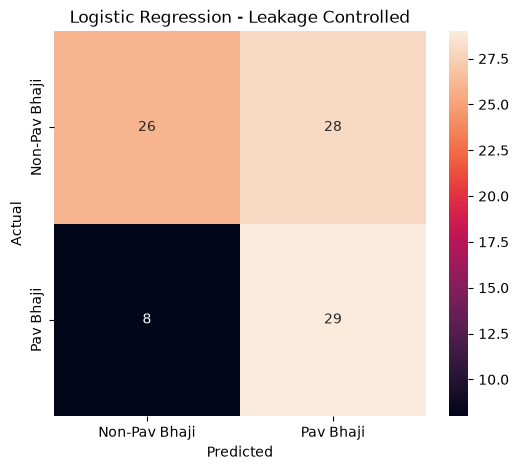

In [43]:
cm_clean = confusion_matrix(y_test_clean, y_pred_lr_clean)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_clean,
    annot=True,
    fmt="d",
    xticklabels=["Non-Pav Bhaji", "Pav Bhaji"],
    yticklabels=["Non-Pav Bhaji", "Pav Bhaji"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Leakage Controlled")
plt.show()

In [44]:
import joblib

model_path = "../models/pavbhaji_text_classifier.pkl"

joblib.dump(tfidf_lr_clean, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/pavbhaji_text_classifier.pkl


In [45]:
def predict_pavbhaji(text):
    cleaned = clean_text(text)
    cleaned = remove_pavbhaji(cleaned)
    prediction = tfidf_lr_clean.predict([cleaned])[0]
    
    if prediction == 1:
        return "Pav Bhaji"
    return "Not Pav Bhaji"

In [46]:
predict_pavbhaji("Delicious Mumbai street food with spicy vegetables and buttered pav")

'Pav Bhaji'

In [47]:
predict_pavbhaji("Fresh chicken tikka with salad and naan for dinner")

'Not Pav Bhaji'

In [48]:
pd.crosstab(ml_df["label"], ml_df["contains_pavbhaji"])

contains_pavbhaji,False,True
label,,
0,2,267
1,0,183


In [49]:
error_df = ml_df.loc[X_test_clean.index].copy()
error_df["actual"] = y_test_clean
error_df["predicted"] = y_pred_lr_clean

errors = error_df[error_df["actual"] != error_df["predicted"]]

print("Total test samples:", len(error_df))
print("Incorrect predictions:", len(errors))
print("Error rate:", round(len(errors) / len(error_df), 4))

Total test samples: 91
Incorrect predictions: 36
Error rate: 0.3956


In [50]:
errors[["image", "actual", "predicted", "caption", "tags"]].head(10)

,image,actual,predicted,caption,tags
72,39192398_1120128498137782_1781545369159598080_n.jpg,0,1,Rakhi special ❤️ Homemade Pav Bhaji 😊\n\nFollow@foodie_punjaban\n\n#rakhi #2018 #foodie #foodblogger #foodlover #foodtalk #foodieforlife #foodporn #nomnom #saharanpur #mazzaaagaya #lovedit #homesw...,"[rakhi, nomnom, saharanpur, foodlover, 2018, homesweethome, foodblogger, tasteatitsbest, moms, foodie, mazzaaagaya, festivalmodeon, bhaibehen, pavbhaji, lovedit, foodporn, foodieforlife, momistheb..."
75,39744547_231289940899288_5133092913563041792_n.jpg,0,1,#cooking #pavbhaji #somethingnew,"[pavbhaji, cooking, somethingnew]"
240,39525726_438548496655066_4753851892646281216_n.jpg,0,1,"#pavbhaji topped with cheese.\n\nPav bhaji is a popular dish from India, consisting of a thick vegetable curry and is served with a soft bread roll.\nAnd...\nMy all time fave drink besides chai in...","[mumbai, foodie, indianfood, lunch, passionpassport, travel, vegetarian, eatout, instafood, solotravel, fastfood, RamKrishna, india, love, food52grams, restaurant, mumbaifood, food, tasty, travelg..."
185,39378694_2186656501618843_8748965522890031104_n.jpg,1,0,The next time ur around Crawford market and hungry after a long shopping session give the old favourite Badshah a miss and satiate your hungerpangs at Sadanand .. Trust me that the food is 10 time...,"[foodofmumbai, bhgfood, foodmaniacindia, delhifoodie, fridaymood, photographers_of_india, hautecuisines, mumbaifoodie, shutuploudly, shoottokill, whatiate, mymumbai, soi, nycfoodie, things2doinmum..."
386,39138498_239937570027979_3896829174895083520_n.jpg,0,1,"Cheating the diet today also 😑 with these....⬅️ Momos from Hari momos and pavbhaji from Lal chat bhandar located in C1-A MarketJanakpuri\n.\n.\n.\nTaste- *Momos- thick layer,less filling but tast...","[momos, spicyfood, food, love, indianfood, streetfood, pavbhaji, lovetoeat, foodies, hotweather, snacks, eveningsnacks]"
381,20590186_1136380956463100_8896999366112313344_n.jpg,1,0,#pavbhaji #pavbhajilove,"[pavbhaji, pavbhajilove]"
259,39242129_227300597947996_2020018089625649152_n.jpg,0,1,"So this special dish was prepared yesterday evening and is dedicated to all those vegetarians out there! Known on Indian streets as Pav Bhaji, its a medley of steamed vegetables, mashed and cooked...","[surreyfood, spices, muddystilettos, food, eat, surrey, cookery, vegetarian, pavbhaji, foodie, streetfood, cooking, curry, foodmemories, delicious, indianfood, cookingclass, homemade, goodfood]"
419,39028851_272170493391426_1607096094087446528_n.jpg,1,0,#pavbhaji,[pavbhaji]
373,38826877_288496381743438_7919164372285390848_n.jpg,1,0,"When it comes to love and food, nothing can beat our dearest mommies..😘😍\n#homemade #pavbhaji #breakfastready\n.\n.\n#foodie #foodism #foodlover #foodislife #foodporn #foodgram #foodinstagram #foo...","[foodgram, foodphotography, delhincr, foodmaniacindia, delhifoodie, foodie, breakfastready, foodaholic, indianfood, likeforlike, foodlover, foodreviewer, exploringdelhi, pinch_of_mazic, foodporn, ..."
336,39486044_443243472830930_236961269934981120_n.jpg,0,1,Pav Bhaji recipe made fresh #pavbhaji #londondiaries🇬🇧 #mumbai #streetfood #vegetables #yummyfoods #cheffoodietrudie #chef #homecooked,"[yummyfoods, vegetables, londondiaries, mumbai, homecooked, streetfood, pavbhaji, chef, cheffoodietrudie]"


In [51]:
print(classification_report(
    y_test_clean,
    y_pred_lr_clean,
    target_names=["Non-Pav Bhaji", "Pav Bhaji"]
))

               precision    recall  f1-score   support

Non-Pav Bhaji       0.76      0.48      0.59        54
    Pav Bhaji       0.51      0.78      0.62        37

     accuracy                           0.60        91
    macro avg       0.64      0.63      0.60        91
 weighted avg       0.66      0.60      0.60        91



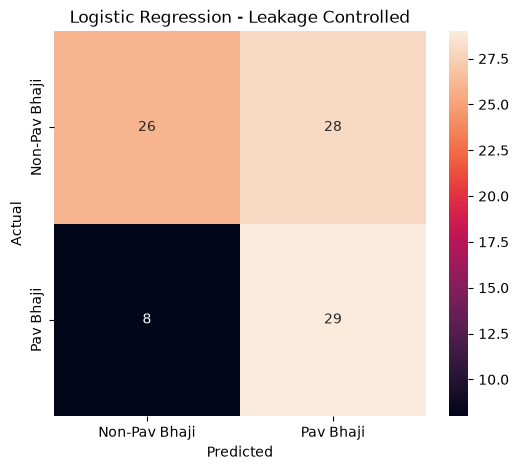

In [52]:
cm_clean = confusion_matrix(y_test_clean, y_pred_lr_clean)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_clean,
    annot=True,
    fmt="d",
    xticklabels=["Non-Pav Bhaji", "Pav Bhaji"],
    yticklabels=["Non-Pav Bhaji", "Pav Bhaji"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Leakage Controlled")
plt.show()

In [53]:
import joblib

model_path = "../models/pavbhaji_text_classifier.pkl"

joblib.dump(tfidf_lr_clean, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/pavbhaji_text_classifier.pkl


In [54]:
def predict_pavbhaji(text):
    cleaned = clean_text(text)
    cleaned = remove_pavbhaji(cleaned)
    prediction = tfidf_lr_clean.predict([cleaned])[0]
    
    if prediction == 1:
        return "Pav Bhaji"
    return "Not Pav Bhaji"

In [55]:
predict_pavbhaji("Delicious Mumbai street food with spicy vegetables and buttered pav")

'Pav Bhaji'

In [57]:
predict_pavbhaji("Fresh chicken tikka with salad and garlic naan for dinner")

'Not Pav Bhaji'

In [58]:
vectorizer = tfidf_lr_clean.named_steps["tfidf"]
model = tfidf_lr_clean.named_steps["model"]

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

positive_features = feature_importance.sort_values(
    "coefficient", ascending=False
).head(20)

negative_features = feature_importance.sort_values(
    "coefficient", ascending=True
).head(20)

positive_features

,feature,coefficient
1136,foodlover,1.155800
1023,foodgasm,0.708643
2871,special,0.706648
2514,pav,0.682132
2145,monsoon,0.669901
863,follow,0.652980
218,bhukkad,0.644039
1962,likeforlikes,0.640891
269,breakfast,0.638982
291,butter,0.616006


In [59]:
negative_features

,feature,coefficient
3219,vadapav,-0.764844
2485,panipuri,-0.717527
207,bhelpuri,-0.686635
902,fondue,-0.635259
2570,pizza,-0.614580
2468,our,-0.572204
2204,mumbaidiaries,-0.499021
2098,masaladosa,-0.478684
1010,foodforlife,-0.471238
1890,kolkatadiaries,-0.452481


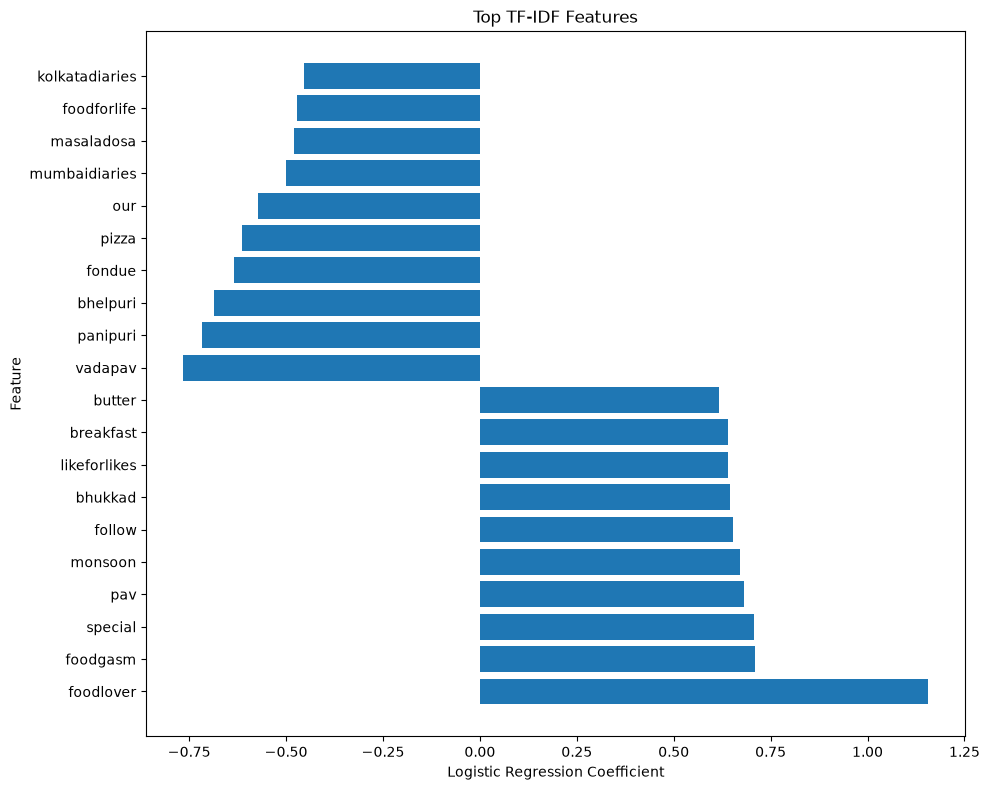

In [60]:
top_features = pd.concat([
    positive_features.head(10),
    negative_features.head(10)
])

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top TF-IDF Features")
plt.tight_layout()
plt.show()

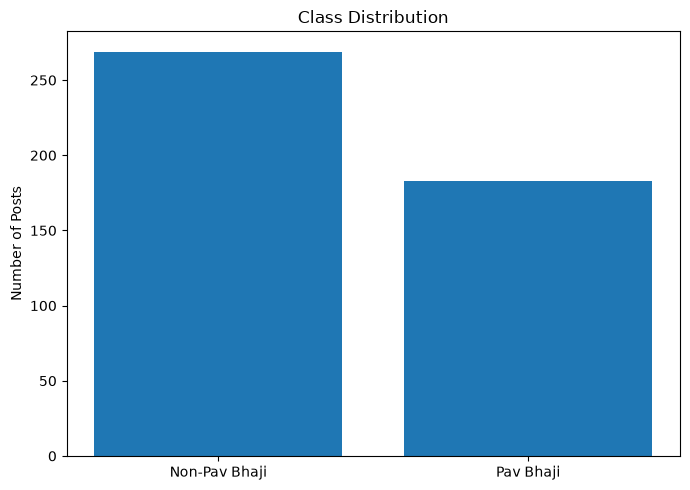

In [61]:
class_counts = ml_df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Non-Pav Bhaji", "Pav Bhaji"],
    class_counts.values
)
plt.ylabel("Number of Posts")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [62]:
ml_df["text_length"] = ml_df["clean_text_no_keyword"].str.len()

In [63]:
ml_df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,269.0,560.855019,283.025705,9.0,383.0,582.0,737.0,1699.0
1,183.0,473.803279,308.531446,0.0,236.5,471.0,671.5,1831.0


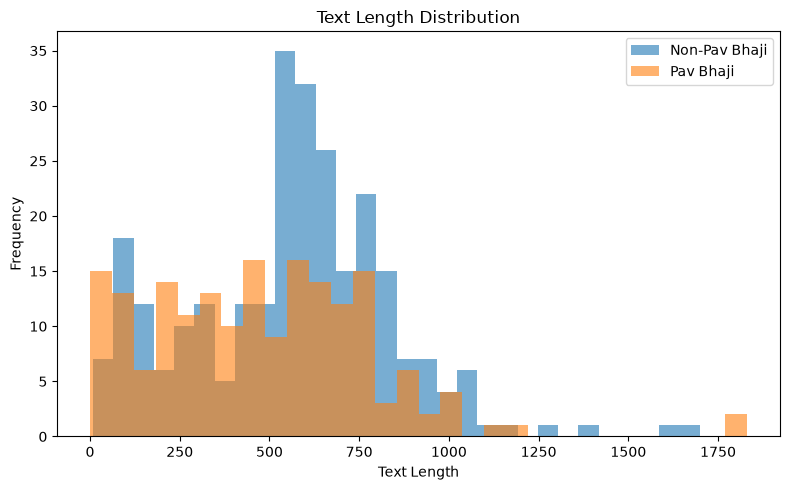

In [64]:
plt.figure(figsize=(8, 5))
plt.hist(
    ml_df[ml_df["label"] == 0]["text_length"],
    bins=30,
    alpha=0.6,
    label="Non-Pav Bhaji"
)
plt.hist(
    ml_df[ml_df["label"] == 1]["text_length"],
    bins=30,
    alpha=0.6,
    label="Pav Bhaji"
)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Text Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
final_results = pd.DataFrame([
    lr_metrics,
    svm_metrics,
    nb_metrics,
    lr_clean_metrics
])

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6264,0.5254,0.8378,0.6458
1,Linear SVM,0.6264,0.5319,0.6757,0.5952
2,Naive Bayes,0.5604,0.4571,0.4324,0.4444
3,Logistic Regression - No Pav Bhaji Keyword,0.6044,0.5088,0.7838,0.6170


In [66]:
final_results.to_csv("../reports/final_model_results.csv", index=False)

In [67]:
errors[[
    "image",
    "actual",
    "predicted",
    "caption",
    "tags"
]].to_csv("../reports/misclassified_samples.csv", index=False)

In [68]:
ml_df.to_csv("../reports/processed_dataset.csv", index=False)